In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-01.csv
/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-03.csv
/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-02.csv
/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2015-01.csv
/kaggle/input/nyc-yellow-taxi-trips-outliers-detection/__results__.html
/kaggle/input/nyc-yellow-taxi-trips-outliers-detection/__resultx__.html
/kaggle/input/nyc-yellow-taxi-trips-outliers-detection/__notebook__.ipynb
/kaggle/input/nyc-yellow-taxi-trips-outliers-detection/__output__.json
/kaggle/input/nyc-yellow-taxi-trips-outliers-detection/custom.css
/kaggle/input/nyc-yellow-taxi-trips-outliers-detection/__results___files/__results___8_0.png
/kaggle/input/nyc-yellow-taxi-trips-outliers-detection/__results___files/__results___20_0.png
/kaggle/input/dataset-taxi/taxi_zone_lookup.csv


In [2]:
import pandas as pd
import dask.dataframe as dd
import time
import os
import glob
import gzip
import shutil


In [3]:
path = "/kaggle/input/nyc-yellow-taxi-trip-data/"
csv_files = glob.glob(path + "yellow_tripdata_*.csv")

print("عدد الملفات:", len(csv_files))
for f in csv_files:
    print(f)


عدد الملفات: 4
/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-01.csv
/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-03.csv
/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-02.csv
/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2015-01.csv


In [4]:
combined_file = "/kaggle/working/combined_yellow_tripdata.csv"

with open(combined_file, 'wb') as outfile:
    for i, file in enumerate(csv_files):
        with open(file, 'rb') as infile:
            if i != 0:
                infile.readline()  # بش نحي تكرار
            shutil.copyfileobj(infile, outfile)

print(f"تم الدمج! الحجم الإجمالي: {os.path.getsize(combined_file)/1e9:.2f} GB")


تم الدمج! الحجم الإجمالي: 7.39 GB


In [5]:
start_time = time.time()

chunks = pd.read_csv(combined_file, chunksize=500000)
rows = 0
for chunk in chunks:
    rows += len(chunk)

end_time = time.time()

print(f"Total rows: {rows}")
print(f"Pandas (chunksize) time: {end_time - start_time:.2f} seconds")


Total rows: 47248845
Pandas (chunksize) time: 162.11 seconds


In [7]:
start_time = time.time()

df_dask = dd.read_csv(combined_file, assume_missing=True)
rows_dask = len(df_dask)
df_dask.head()

end_time = time.time()

print(f"Dask read time: {end_time - start_time:.2f} seconds")


Dask read time: 100.64 seconds


In [8]:
compressed_file = "/kaggle/working/combined_yellow_tripdata.csv.gz"
with open(combined_file, 'rb') as f_in:
    with gzip.open(compressed_file, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print(f"Compressed size: {os.path.getsize(compressed_file)/1e9:.2f} GB")

start_time = time.time()
df_gzip = pd.read_csv(compressed_file, compression='gzip', nrows=100000)
end_time = time.time()

print(f"Pandas read gzip time: {end_time - start_time:.2f} seconds")


Compressed size: 1.84 GB
Pandas read gzip time: 0.59 seconds


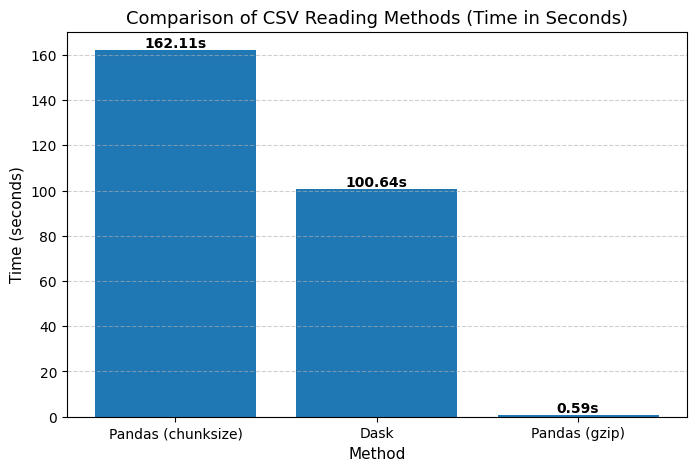

In [9]:
import matplotlib.pyplot as plt

methods = ["Pandas (chunksize)", "Dask", "Pandas (gzip)"]
times = [162.11, 100.64, 0.59]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, times)

# إضافة القيم فوق الأعمدة
for bar, time in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{time:.2f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Comparison of CSV Reading Methods (Time in Seconds)", fontsize=13)
plt.xlabel("Method", fontsize=11)
plt.ylabel("Time (seconds)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
